In [ ]:
!pip install tqdm

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#  LOAD DATA
X = np.load("X_beats.npy")        # (N, 216)
y = np.load("y_labels.npy")       # (N,)

# Normalize per beat
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).unsqueeze(1)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

In [ ]:
#  BALANCED SAMPLER (FIXES IMBALANCE!!)

class_sample_counts = np.bincount(y_train)
class_weights = 1.0 / class_sample_counts
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

In [ ]:

#  MODEL DEFINITION (same as yours)
class ECG1DCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

model = ECG1DCNN(num_classes=4).to(device)


#  FOCAL LOSS (stable version)
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, labels):
        ce = nn.CrossEntropyLoss(weight=self.alpha, reduction="none")(logits, labels)
        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        return focal.mean()

#  SAFE CLASS WEIGHTS
# Not extreme like 1/count, this is stable
alpha_weights = torch.tensor([1.0, 6.0, 3.0, 8.0], dtype=torch.float32).to(device)

criterion = FocalLoss(alpha=alpha_weights, gamma=2)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)


In [ ]:

#  TRAINING LOOP
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in tqdm(loader, leave=False):
        xb, yb = xb.to(device), yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total


best_val = 0
for epoch in range(1, 41):  # Train for 40 epochs
    print(f"\nEpoch {epoch}/40")

    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    print(f"Train Loss {tr_loss:.4f} | Train Acc {tr_acc*100:.2f}%")
    print(f"Val   Loss {val_loss:.4f} | Val   Acc {val_acc*100:.2f}%")

    scheduler.step(val_loss)

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_ecg_1dcnn_balanced.pth")
        print("Saved best model.")

print("\nTraining Completed!")

In [ ]:
model.load_state_dict(torch.load("best_ecg_1dcnn_balanced.pth"))
model.eval()

label_map = {0:'N',1:'S',2:'V',3:'F'}

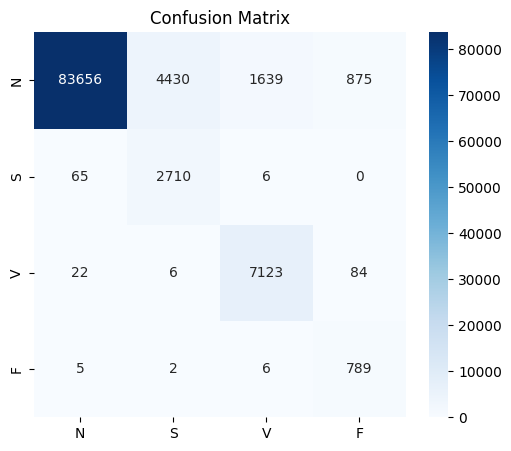


Classification Report:
              precision    recall  f1-score   support

           N       1.00      0.92      0.96     90600
           S       0.38      0.97      0.55      2781
           V       0.81      0.98      0.89      7235
           F       0.45      0.98      0.62       802

    accuracy                           0.93    101418
   macro avg       0.66      0.97      0.75    101418
weighted avg       0.96      0.93      0.94    101418



In [7]:
#  CONFUSION MATRIX + CLASSIFICATION REPORT
all_preds = []
all_true = []

for i in range(len(X)):
    beat = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(beat).argmax(1).item()
    all_preds.append(pred)
    all_true.append(int(y[i]))

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['N','S','V','F'],
            yticklabels=['N','S','V','F'])
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=['N','S','V','F']))


Index: 22588
Predicted: F
Actual:    F


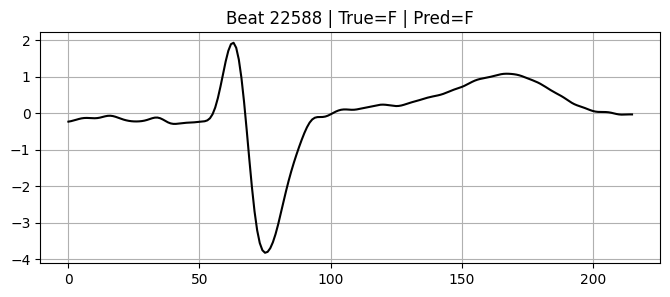

3

In [11]:
#  PREDICT SINGLE BEAT + VISUALIZATION
def predict_single_beat(idx):
    beat = X[idx]
    beat_norm = (beat - beat.mean()) / (beat.std() + 1e-8)

    inp = torch.tensor(beat_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(inp).argmax(1).item()

    print(f"Index: {idx}")
    print(f"Predicted: {label_map[pred]}")
    print(f"Actual:    {label_map[y[idx]]}")

    plt.figure(figsize=(8,3))
    plt.plot(beat, color="black")
    plt.title(f"Beat {idx} | True={label_map[y[idx]]} | Pred={label_map[pred]}")
    plt.grid(True)
    plt.show()

    return pred

# Example:
predict_single_beat(22588)

In [26]:
#  GRAD-CAM EXPLAINABILITY FOR ECG
class ECGGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # SAFE HOOKS
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        out = self.model(input_tensor)
        out[0, class_idx].backward()

        # activations shape: (1, C, T)
        # gradients shape:   (1, C, T)

        weights = self.gradients.mean(dim=2, keepdim=True)   # (1, C, 1)
        cam = (weights * self.activations).sum(dim=1).squeeze()  # (T,)

        cam = cam.cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


In [31]:
gradcam = ECGGradCAM(model, model.conv2[0])

In [32]:
def plot_gradcam(idx):
    beat = X[idx]
    beat_norm = (beat - beat.mean()) / (beat.std() + 1e-8)

    inp = torch.tensor(beat_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    pred = model(inp).argmax(1).item()
    cam = gradcam.generate(inp, pred)

    # Resize CAM from 54 → 216
    cam = np.interp(np.arange(len(beat)),
                    np.linspace(0, len(beat)-1, len(cam)),
                    cam)

    plt.figure(figsize=(12,4))
    plt.plot(beat, color="black")

    for i in range(len(beat)-1):
        plt.plot([i, i+1], [beat[i], beat[i+1]], color=(cam[i], 0, 0), linewidth=3)

    plt.title(f"Grad-CAM | True={label_map[y[idx]]} | Pred={label_map[pred]}")
    plt.show()


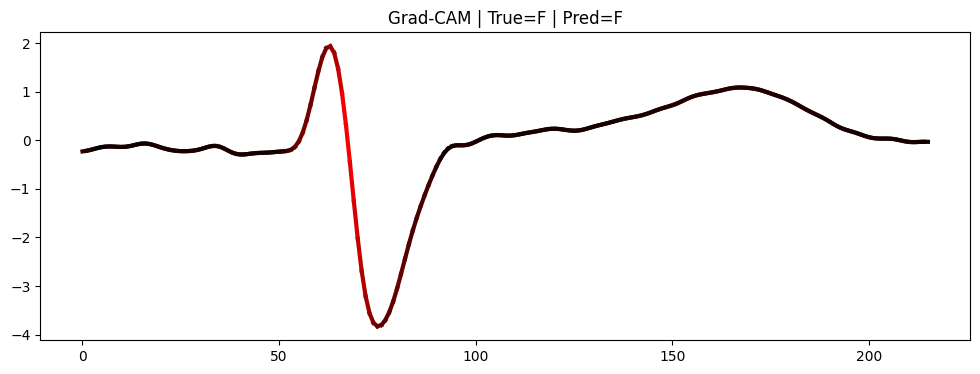

In [33]:
plot_gradcam(22588)